## Setup and Imports

Load libraries required for regression modeling, evaluation, diagnostics, and visualization.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

## Load Processed Data

Load the pre-race feature store for finishing-position prediction.

In [9]:
df = pd.read_parquet("data_processed/f1_feature_store_prerace.parquet")
df["date"] = pd.to_datetime(df["date"], errors="coerce")

df.shape
df.head()

,raceId,driverId,constructorId,circuitId,date,year,round,target_points,finish_position,positionOrder,...,wind_speed,humidity_avg,month,is_wet_race,high_altitude_track,sprint_grid,sprint_position_order,sprint_points,sprint_laps,sprint_milliseconds
0,18,1,1,1,2008-03-16,2008,1,1,1,1,...,23.1,41.0,3,0,0,NaN,NaN,NaN,NaN,NaN
1,18,2,2,1,2008-03-16,2008,1,1,2,2,...,23.1,41.0,3,0,0,NaN,NaN,NaN,NaN,NaN
2,18,3,3,1,2008-03-16,2008,1,1,3,3,...,23.1,41.0,3,0,0,NaN,NaN,NaN,NaN,NaN
3,18,4,4,1,2008-03-16,2008,1,1,4,4,...,23.1,41.0,3,0,0,NaN,NaN,NaN,NaN,NaN
4,18,5,1,1,2008-03-16,2008,1,1,5,5,...,23.1,41.0,3,0,0,NaN,NaN,NaN,NaN,NaN


## Define Target Variable

Define finishing position as the regression target using position order.

In [10]:
df["finish_position"] = pd.to_numeric(df["finish_position"], errors="coerce")

## Target Distribution

Examine the distribution of finishing positions to understand shape and spread.

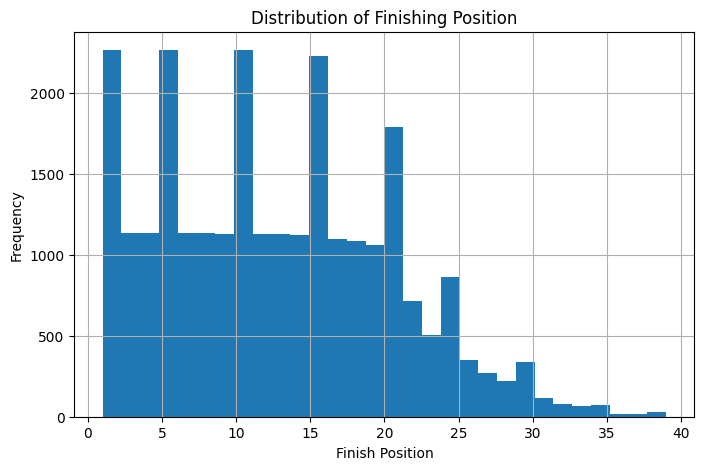

In [11]:
plt.figure(figsize=(8, 5))
df["finish_position"].dropna().hist(bins=30)
plt.title("Distribution of Finishing Position")
plt.xlabel("Finish Position")
plt.ylabel("Frequency")
plt.show()

In [12]:
df["finish_position"].describe()

count    26759.000000
mean        12.794051
std          7.665951
min          1.000000
25%          6.000000
50%         12.000000
75%         18.000000
max         39.000000
Name: finish_position, dtype: float64

## Feature Selection

Select numerical features capturing starting position, performance, reliability, and environmental conditions. Define the pre-race feature set used for finishing-position prediction.

In [13]:
[c for c in df.columns if "grid" in c.lower() or "qual" in c.lower() or "dnf" in c.lower() or "points_last" in c.lower() or "finish_last" in c.lower()]

['grid',
 'grid_clean',
 'qualifying_position',
 'best_qualifying_time_ms',
 'driver_avg_finish_last5',
 'driver_points_last5',
 'driver_dnf_rate_last5',
 'driver_avg_grid_last5',
 'constructor_points_last5',
 'constructor_dnf_rate_last5',
 'constructor_avg_finish_last5',
 'sprint_grid']

In [18]:
features_core = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "driver_points_last5",
    "driver_dnf_rate_last5",
    "constructor_points_last5",
    "constructor_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "alt",
    "abs_lat",
    "temp_avg",
    "temp_range",
    "precipitation",
    "humidity_avg",
    "wind_speed",
    "is_wet_race",
    "high_altitude_track",
    "year"
]

model_df = df[["finish_position"] + features_core].copy()

for col in model_df.columns:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.dropna().copy()

model_df.shape

(9714, 19)

In [19]:
features_core = [...]

In [20]:
features_plus_standings = features_core + [
    "driver_standing_points_prerace",
    "driver_standing_position_prerace",
    "driver_standing_wins_prerace",
    "constructor_standing_points_prerace",
    "constructor_standing_position_prerace",
    "constructor_standing_wins_prerace"
]

In [21]:
features_plus_qual_detail = features_plus_standings + [
    "best_qualifying_time_ms",
    "made_q2",
    "made_q3"
]

In [22]:
missing_summary = (
    model_df.isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame("missing_pct")
)

missing_summary

model_df.notna().sum().sort_values()

finish_position                 9714
grid_clean                      9714
qualifying_position             9714
driver_avg_finish_last5         9714
driver_points_last5             9714
driver_dnf_rate_last5           9714
constructor_points_last5        9714
constructor_dnf_rate_last5      9714
constructor_avg_finish_last5    9714
alt                             9714
abs_lat                         9714
temp_avg                        9714
temp_range                      9714
precipitation                   9714
humidity_avg                    9714
wind_speed                      9714
is_wet_race                     9714
high_altitude_track             9714
year                            9714
dtype: int64

In [23]:
missing_summary

,missing_pct
finish_position,0.0
grid_clean,0.0
qualifying_position,0.0
driver_avg_finish_last5,0.0
driver_points_last5,0.0
driver_dnf_rate_last5,0.0
constructor_points_last5,0.0
constructor_dnf_rate_last5,0.0
constructor_avg_finish_last5,0.0
alt,0.0


## Train-Test Split

Use a time-based split to simulate real-world prediction.

In [27]:
set(features_core) - set(model_df.columns)

{Ellipsis}

In [28]:
features_core = [
    "grid_clean",
    "qualifying_position",
    "driver_avg_finish_last5",
    "driver_points_last5",
    "driver_dnf_rate_last5",
    "constructor_points_last5",
    "constructor_dnf_rate_last5",
    "constructor_avg_finish_last5",
    "alt",
    "abs_lat",
    "temp_avg",
    "temp_range",
    "precipitation",
    "humidity_avg",
    "wind_speed",
    "is_wet_race",
    "high_altitude_track",
    "year"
]

model_df = df[["finish_position"] + features_core].copy()

for col in model_df.columns:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.dropna().copy()

train = model_df[model_df["year"] <= 2021].copy()
test = model_df[model_df["year"] >= 2022].copy()

X_train = train[features_core]
y_train = train["finish_position"]

X_test = test[features_core]
y_test = test["finish_position"]

X_train.shape, X_test.shape

((8451, 18), (1263, 18))

## Linear Regression Baseline

Fit a multiple linear regression model using pre-race features to establish a baseline for predicting finishing position.

This model assumes a linear relationship between features and outcome and serves as a benchmark for more flexible models.

In [30]:
lr = LinearRegression()
lr.fit(X_train, y_train)

preds_lr = lr.predict(X_test)

## Model Evaluation

Evaluate model performance using standard regression metrics:

- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- R² (Coefficient of Determination)

These metrics quantify prediction error and explanatory power on the test set.

In [31]:
rmse_lr = np.sqrt(mean_squared_error(y_test, preds_lr))
mae_lr = mean_absolute_error(y_test, preds_lr)
r2_lr = r2_score(y_test, preds_lr)

pd.DataFrame({
    "metric": ["RMSE", "MAE", "R2"],
    "linear_regression": [rmse_lr, mae_lr, r2_lr]
})

,metric,linear_regression
0,RMSE,4.188144
1,MAE,3.145587
2,R2,0.479608


## Residual Diagnostics

Analyze residuals to assess model fit and identify potential violations of linear assumptions, including:

- Nonlinearity
- Heteroskedasticity
- Outliers

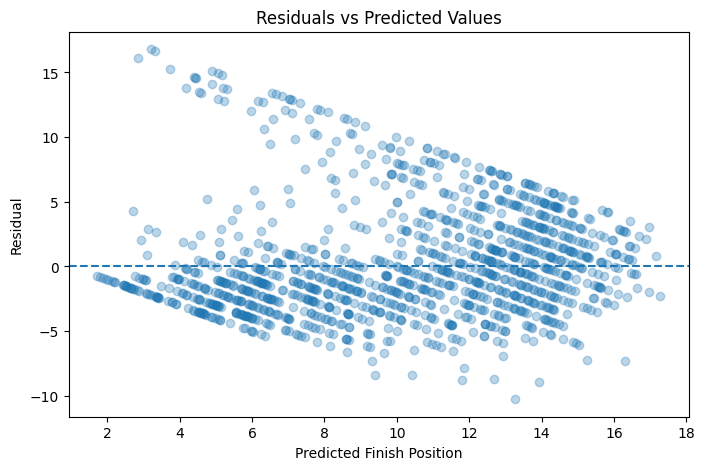

In [32]:
residuals_lr = y_test - preds_lr

plt.figure(figsize=(8, 5))
plt.scatter(preds_lr, residuals_lr, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted Finish Position")
plt.ylabel("Residual")
plt.show()

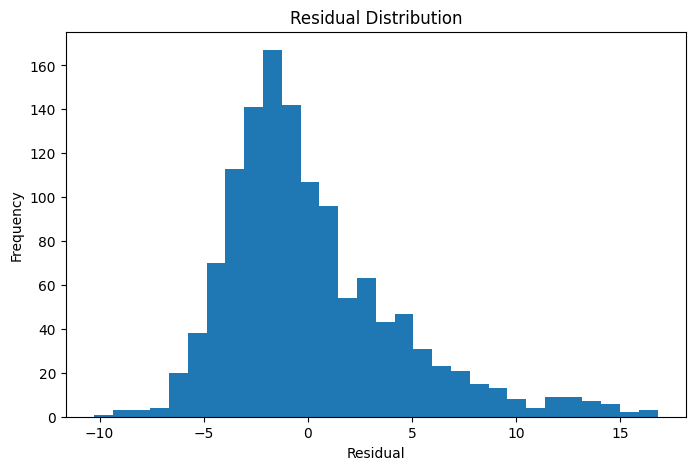

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(residuals_lr, bins=30)
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

## Tree-Based Regression Model

Fit a gradient boosting model (XGBoost) to capture nonlinear relationships and interaction effects between features.

This model relaxes the linearity assumption and can model complex patterns in the data.

In [34]:
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

preds_xgb = xgb.predict(X_test)

## Model Comparison

Compare linear and tree-based models using the same evaluation metrics to assess relative performance and model flexibility.

In [35]:
rmse_xgb = np.sqrt(mean_squared_error(y_test, preds_xgb))
mae_xgb = mean_absolute_error(y_test, preds_xgb)
r2_xgb = r2_score(y_test, preds_xgb)

comparison = pd.DataFrame({
    "metric": ["RMSE", "MAE", "R2"],
    "linear_regression": [rmse_lr, mae_lr, r2_lr],
    "xgboost": [rmse_xgb, mae_xgb, r2_xgb]
})

comparison

,metric,linear_regression,xgboost
0,RMSE,4.188144,4.285724
1,MAE,3.145587,3.264129
2,R2,0.479608,0.455076


## Feature Importance

Extract feature importance from the tree-based model to identify which inputs contribute most to predictive performance.

Importance is based on how frequently and effectively features are used in decision splits.

In [36]:
importance = pd.DataFrame({
    "feature": features_core,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)

importance

,feature,importance
1,qualifying_position,0.285609
0,grid_clean,0.231212
2,driver_avg_finish_last5,0.056963
15,is_wet_race,0.050315
5,constructor_points_last5,0.045780
3,driver_points_last5,0.045106
17,year,0.031628
7,constructor_avg_finish_last5,0.031624
9,abs_lat,0.026562
11,temp_range,0.026311


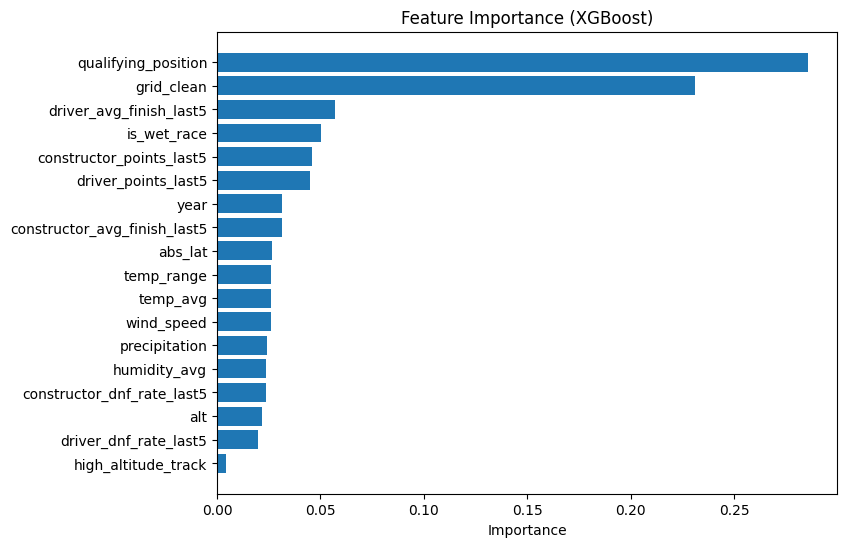

In [37]:
plt.figure(figsize=(8, 6))
plt.barh(importance["feature"], importance["importance"])
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

## Predicted vs Actual

Compare predicted and observed finishing positions to assess model calibration and overall fit.

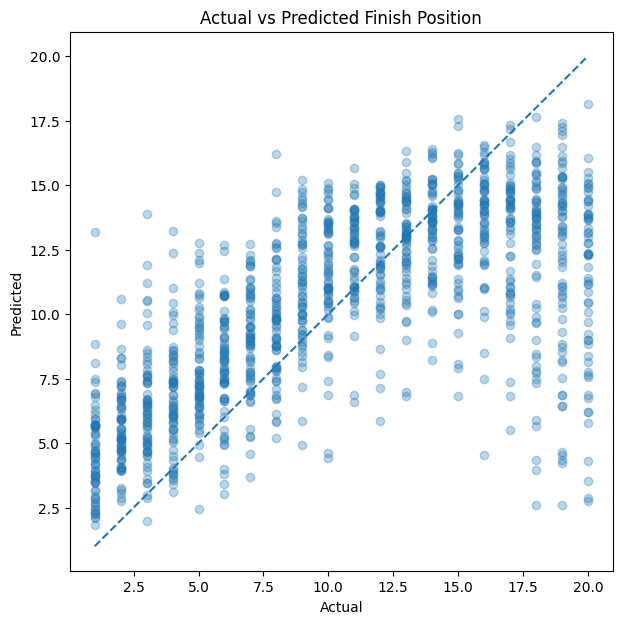

In [38]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds_xgb, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.title("Actual vs Predicted Finish Position")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

## Bootstrap Stability

Estimate variability in model performance by resampling the test set and recomputing RMSE.

This provides a measure of model stability and robustness.

In [39]:
boot_rmse = []

for _ in range(100):
    sample = test.sample(frac=1, replace=True)
    X_sample = sample[features_core]
    y_sample = sample["finish_position"]

    preds_sample = xgb.predict(X_sample)

    boot_rmse.append(np.sqrt(mean_squared_error(y_sample, preds_sample)))

np.mean(boot_rmse), np.std(boot_rmse)

(4.2843162017569965, 0.11749275729610702)

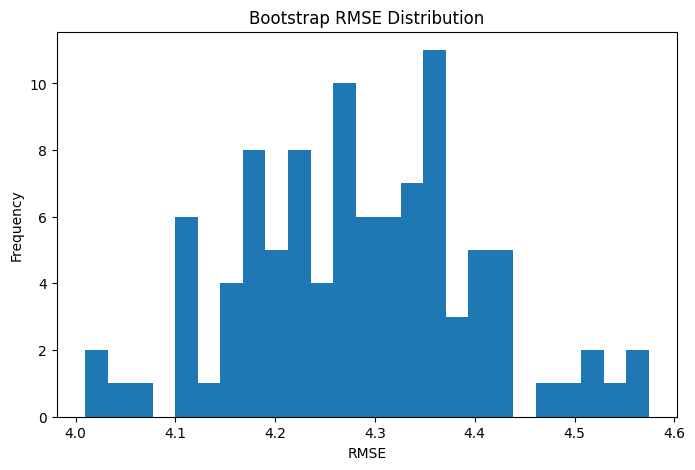

In [40]:
plt.figure(figsize=(8, 5))
plt.hist(boot_rmse, bins=25)
plt.title("Bootstrap RMSE Distribution")
plt.xlabel("RMSE")
plt.ylabel("Frequency")
plt.show()

## Cross-Validation Strategy

Evaluate model performance using time-aware cross-validation to ensure robustness across different temporal splits.

This approach avoids leakage and provides a more reliable estimate of model generalization.

In [41]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

tscv

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)

## Cross-Validated Linear Regression

Evaluate linear regression performance across multiple temporal splits using RMSE.

In [42]:
from sklearn.base import clone

rmse_scores_lr = []

for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, preds))
    rmse_scores_lr.append(rmse)

np.mean(rmse_scores_lr), np.std(rmse_scores_lr)

(5.167323178793683, 0.6235794314914319)

## Cross-Validated XGBoost

Evaluate gradient boosting performance across temporal folds.

In [43]:
rmse_scores_xgb = []

for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, preds))
    rmse_scores_xgb.append(rmse)

np.mean(rmse_scores_xgb), np.std(rmse_scores_xgb)

(5.2760578559442965, 0.6372922669134887)

## K-Nearest Neighbors Regression

Fit a distance-based model to capture local patterns in the feature space.

KNN does not assume a functional form and can capture nonlinear relationships through proximity.

In [44]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=10))
])

knn_pipeline.fit(X_train, y_train)

preds_knn = knn_pipeline.predict(X_test)

## Evaluate KNN Model

Assess KNN performance using the same regression metrics.

In [45]:
rmse_knn = np.sqrt(mean_squared_error(y_test, preds_knn))
mae_knn = mean_absolute_error(y_test, preds_knn)
r2_knn = r2_score(y_test, preds_knn)

rmse_knn, mae_knn, r2_knn

(4.394437028934062, 3.377434679334917, 0.4270799424320484)

## Cross-Validated KNN

Evaluate KNN performance across temporal folds.

In [46]:
rmse_scores_knn = []

for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=10))
    ])

    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, preds))
    rmse_scores_knn.append(rmse)

np.mean(rmse_scores_knn), np.std(rmse_scores_knn)

(5.396883624618436, 0.5926318277265065)

## Model Comparison

Compare all models using both test performance and cross-validation results.

In [47]:
cv_summary = pd.DataFrame({
    "model": ["Linear Regression", "XGBoost", "KNN"],
    "cv_rmse_mean": [
        np.mean(rmse_scores_lr),
        np.mean(rmse_scores_xgb),
        np.mean(rmse_scores_knn)
    ],
    "cv_rmse_std": [
        np.std(rmse_scores_lr),
        np.std(rmse_scores_xgb),
        np.std(rmse_scores_knn)
    ],
    "test_rmse": [rmse_lr, rmse_xgb, rmse_knn],
    "test_mae": [mae_lr, mae_xgb, mae_knn],
    "test_r2": [r2_lr, r2_xgb, r2_knn]
})

cv_summary.sort_values("test_rmse")

,model,cv_rmse_mean,cv_rmse_std,test_rmse,test_mae,test_r2
0,Linear Regression,5.167323,0.623579,4.188144,3.145587,0.479608
1,XGBoost,5.276058,0.637292,4.285724,3.264129,0.455076
2,KNN,5.396884,0.592632,4.394437,3.377435,0.427080


## Ridge Regression Test

In [48]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

preds_ridge = ridge.predict(X_test)

## Cross-Validation Metrics Expansion

Extend cross-validation evaluation to include MAE and R² in addition to RMSE.

This provides a more complete view of model performance, capturing:
- magnitude of errors (MAE)
- variance explained (R²)
- sensitivity to large errors (RMSE)

In [49]:
#Linear Regression (CV MAE + R²)

mae_scores_lr = []
r2_scores_lr = []

for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = LinearRegression()
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    mae_scores_lr.append(mean_absolute_error(y_val, preds))
    r2_scores_lr.append(r2_score(y_val, preds))

np.mean(mae_scores_lr), np.std(mae_scores_lr), np.mean(r2_scores_lr), np.std(r2_scores_lr)

(3.986301663542379,
 0.5713296990609341,
 0.33329946116841913,
 0.09809347414000082)

In [50]:
#Linear Regression (CV MAE + R²)

mae_scores_xgb = []
r2_scores_xgb = []

for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    mae_scores_xgb.append(mean_absolute_error(y_val, preds))
    r2_scores_xgb.append(r2_score(y_val, preds))

np.mean(mae_scores_xgb), np.std(mae_scores_xgb), np.mean(r2_scores_xgb), np.std(r2_scores_xgb)

(4.113418436050415,
 0.5274305505340915,
 0.3049507737159729,
 0.10333549787011313)

In [52]:
#KNN (CV MAE + R²)

mae_scores_knn = []
r2_scores_knn = []

for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=10))
    ])

    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)

    mae_scores_knn.append(mean_absolute_error(y_val, preds))
    r2_scores_knn.append(r2_score(y_val, preds))

np.mean(mae_scores_knn), np.std(mae_scores_knn), np.mean(r2_scores_knn), np.std(r2_scores_knn)

(4.254176136363637, 0.5429788276087797, 0.272491796610586, 0.0962497520219793)

In [53]:
cv_summary_expanded = pd.DataFrame({
    "model": ["Linear Regression", "XGBoost", "KNN"],

    "cv_rmse_mean": [
        np.mean(rmse_scores_lr),
        np.mean(rmse_scores_xgb),
        np.mean(rmse_scores_knn)
    ],
    "cv_rmse_std": [
        np.std(rmse_scores_lr),
        np.std(rmse_scores_xgb),
        np.std(rmse_scores_knn)
    ],

    "cv_mae_mean": [
        np.mean(mae_scores_lr),
        np.mean(mae_scores_xgb),
        np.mean(mae_scores_knn)
    ],
    "cv_mae_std": [
        np.std(mae_scores_lr),
        np.std(mae_scores_xgb),
        np.std(mae_scores_knn)
    ],

    "cv_r2_mean": [
        np.mean(r2_scores_lr),
        np.mean(r2_scores_xgb),
        np.mean(r2_scores_knn)
    ],
    "cv_r2_std": [
        np.std(r2_scores_lr),
        np.std(r2_scores_xgb),
        np.std(r2_scores_knn)
    ],

    "test_rmse": [rmse_lr, rmse_xgb, rmse_knn],
    "test_mae": [mae_lr, mae_xgb, mae_knn],
    "test_r2": [r2_lr, r2_xgb, r2_knn]
})

cv_summary_expanded.sort_values("test_rmse")

,model,cv_rmse_mean,cv_rmse_std,cv_mae_mean,cv_mae_std,cv_r2_mean,cv_r2_std,test_rmse,test_mae,test_r2
0,Linear Regression,5.167323,0.623579,3.986302,0.571330,0.333299,0.098093,4.188144,3.145587,0.479608
1,XGBoost,5.276058,0.637292,4.113418,0.527431,0.304951,0.103335,4.285724,3.264129,0.455076
2,KNN,5.396884,0.592632,4.254176,0.542979,0.272492,0.096250,4.394437,3.377435,0.427080


## Cross-Validation Summary

Cross-validation results indicate that linear regression consistently outperforms both tree-based and distance-based models across RMSE, MAE, and R² metrics.

Performance differences between models are stable across folds, as reflected by relatively low standard deviations in cross-validation scores.

The consistency between cross-validation metrics and test set performance suggests that model behavior generalizes well across time-based splits.

Overall, model performance appears to be driven more by feature quality than by model complexity.

1. Linear regression wins
Lower RMSE, MAE, higher R²
More stable across folds

This means:
feature engineering linearized the problem.

2. XGBoost does NOT outperform
Slightly worse across all metrics
Similar variance → not unstable, just unnecessary

Interpretation:
There are limited nonlinear interactions left to capture.

3. KNN struggles (as expected)
Worse across all metrics

Due to:
high-dimensional feature space
distance metrics break down
noisy neighbors (different eras, tracks, etc.)

4. CV vs Test gap

Example (Linear):
CV RMSE ≈ 5.17
Test RMSE ≈ 4.19

Test is better than CV — this means:
recent years are more predictable
modern F1 is more structured (regulations, parity, etc.)



## Model-Predicted Outcome vs Qualifying Position

Visualize how predicted finishing position varies as a function of qualifying position, holding other variables constant.

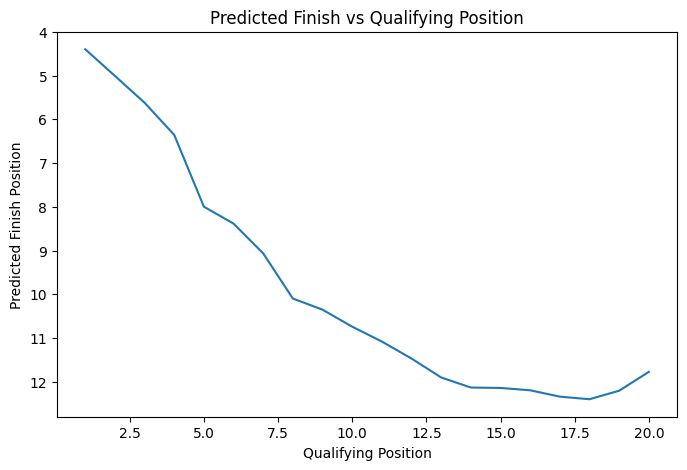

In [54]:
import numpy as np

# Create synthetic input
qual_range = np.arange(1, 21)

sample_row = X_test.mean().to_frame().T

curve_data = []

for q in qual_range:
    temp = sample_row.copy()
    temp["qualifying_position"] = q
    temp["grid_clean"] = q

    pred = xgb.predict(temp)[0]

    curve_data.append((q, pred))

curve_df = pd.DataFrame(curve_data, columns=["qualifying_position", "predicted_finish"])

plt.figure(figsize=(8,5))
plt.plot(curve_df["qualifying_position"], curve_df["predicted_finish"])
plt.gca().invert_yaxis()
plt.title("Predicted Finish vs Qualifying Position")
plt.xlabel("Qualifying Position")
plt.ylabel("Predicted Finish Position")
plt.show()

## Weather Impact on Predicted Outcome

Compare predicted finishing position under wet and dry conditions.

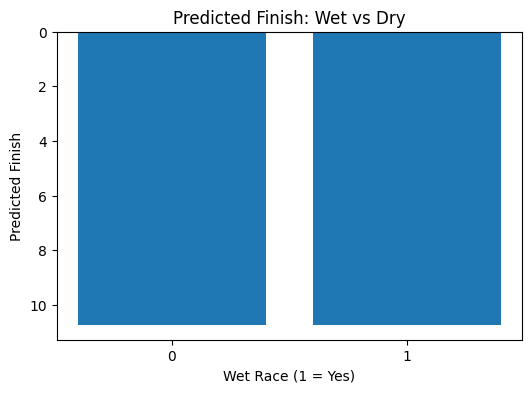

In [55]:
wet_dry_data = []

for wet in [0, 1]:
    temp = sample_row.copy()
    temp["is_wet_race"] = wet

    pred = xgb.predict(temp)[0]

    wet_dry_data.append((wet, pred))

wet_df = pd.DataFrame(wet_dry_data, columns=["is_wet_race", "predicted_finish"])

plt.figure(figsize=(6,4))
plt.bar(wet_df["is_wet_race"].astype(str), wet_df["predicted_finish"])
plt.gca().invert_yaxis()
plt.title("Predicted Finish: Wet vs Dry")
plt.xlabel("Wet Race (1 = Yes)")
plt.ylabel("Predicted Finish")
plt.show()

## Feature Effect: Starting Grid Position

Examine how starting grid position influences predicted finishing position.

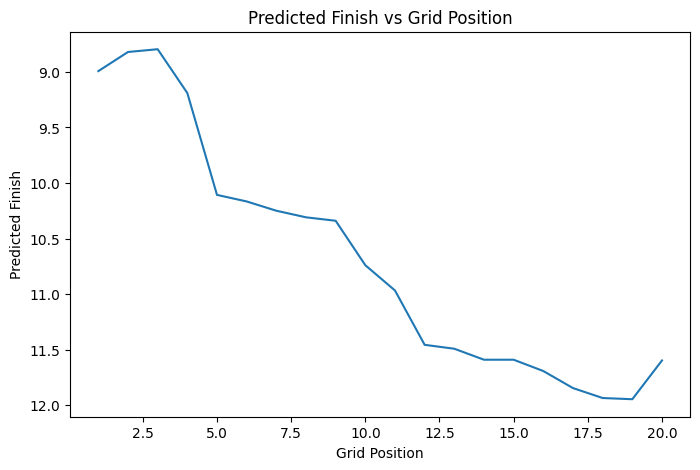

In [56]:
grid_range = np.arange(1, 21)

grid_data = []

for g in grid_range:
    temp = sample_row.copy()
    temp["grid_clean"] = g

    pred = xgb.predict(temp)[0]

    grid_data.append((g, pred))

grid_df = pd.DataFrame(grid_data, columns=["grid", "predicted_finish"])

plt.figure(figsize=(8,5))
plt.plot(grid_df["grid"], grid_df["predicted_finish"])
plt.gca().invert_yaxis()
plt.title("Predicted Finish vs Grid Position")
plt.xlabel("Grid Position")
plt.ylabel("Predicted Finish")
plt.show()

## Export Visualizations

Save all generated plots into a single PDF document for presentation and sharing.

In [57]:
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = "data_processed/f1_model_visuals.pdf"

with PdfPages(pdf_path) as pdf:

    # --- 1. Residual Plot ---
    plt.figure(figsize=(8, 5))
    plt.scatter(preds_lr, residuals_lr, alpha=0.3)
    plt.axhline(0, linestyle="--")
    plt.title("Residuals vs Predicted (Linear Regression)")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    pdf.savefig()
    plt.close()

    # --- 2. Residual Distribution ---
    plt.figure(figsize=(8, 5))
    plt.hist(residuals_lr, bins=30)
    plt.title("Residual Distribution")
    pdf.savefig()
    plt.close()

    # --- 3. Actual vs Predicted ---
    plt.figure(figsize=(7, 7))
    plt.scatter(y_test, preds_xgb, alpha=0.3)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--"
    )
    plt.title("Actual vs Predicted (XGBoost)")
    pdf.savefig()
    plt.close()

    # --- 4. Feature Importance ---
    plt.figure(figsize=(8, 6))
    plt.barh(importance["feature"], importance["importance"])
    plt.title("Feature Importance")
    plt.gca().invert_yaxis()
    pdf.savefig()
    plt.close()

    # --- 5. Qualifying Curve ---
    plt.figure(figsize=(8, 5))
    plt.plot(curve_df["qualifying_position"], curve_df["predicted_finish"])
    plt.gca().invert_yaxis()
    plt.title("Predicted Finish vs Qualifying Position")
    pdf.savefig()
    plt.close()

    # --- 6. Wet vs Dry ---
    plt.figure(figsize=(6, 4))
    plt.bar(wet_df["is_wet_race"].astype(str), wet_df["predicted_finish"])
    plt.gca().invert_yaxis()
    plt.title("Wet vs Dry Race Impact")
    pdf.savefig()
    plt.close()

    # --- 7. Grid Effect ---
    plt.figure(figsize=(8, 5))
    plt.plot(grid_df["grid"], grid_df["predicted_finish"])
    plt.gca().invert_yaxis()
    plt.title("Predicted Finish vs Grid Position")
    pdf.savefig()
    plt.close()

print(f"Saved PDF to: {pdf_path}")

Saved PDF to: data_processed/f1_model_visuals.pdf


In [58]:
import os

output_dir = "data_processed/figures"
os.makedirs(output_dir, exist_ok=True)

In [61]:
import os

# Create output directory
output_dir = "data_processed/figures"
os.makedirs(output_dir, exist_ok=True)


# --- Helper function for consistent styling ---
def save_plot(filename):
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{filename}", dpi=300, bbox_inches="tight")
    plt.close()


# --- 1. Residuals vs Predicted ---
plt.figure(figsize=(8, 5))
plt.scatter(preds_lr, residuals_lr, alpha=0.3)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Predicted (Linear Regression)", fontsize=14, weight="bold")
plt.xlabel("Predicted Finish Position")
plt.ylabel("Residual")
save_plot("01_residuals_vs_predicted.jpg")


# --- 2. Residual Distribution ---
plt.figure(figsize=(8, 5))
plt.hist(residuals_lr, bins=30)
plt.title("Residual Distribution", fontsize=14, weight="bold")
plt.xlabel("Residual")
plt.ylabel("Frequency")
save_plot("02_residual_distribution.jpg")


# --- 3. Actual vs Predicted ---
plt.figure(figsize=(7, 7))
plt.scatter(y_test, preds_xgb, alpha=0.3)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.title("Actual vs Predicted (XGBoost)", fontsize=14, weight="bold")
plt.xlabel("Actual Finish Position")
plt.ylabel("Predicted Finish Position")
save_plot("03_actual_vs_predicted.jpg")


# --- 4. Feature Importance ---
plt.figure(figsize=(8, 6))
plt.barh(importance["feature"], importance["importance"])
plt.title("Feature Importance (XGBoost)", fontsize=14, weight="bold")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
save_plot("04_feature_importance.jpg")


# --- 5. Predicted vs Qualifying Position ---
plt.figure(figsize=(8, 5))
plt.plot(curve_df["qualifying_position"], curve_df["predicted_finish"])
plt.gca().invert_yaxis()
plt.title("Predicted Finish vs Qualifying Position", fontsize=14, weight="bold")
plt.xlabel("Qualifying Position")
plt.ylabel("Predicted Finish Position")
save_plot("05_qualifying_effect.jpg")


# --- 6. Wet vs Dry Race Impact ---
plt.figure(figsize=(6, 4))
plt.bar(wet_df["is_wet_race"].astype(str), wet_df["predicted_finish"])
plt.gca().invert_yaxis()
plt.title("Predicted Finish: Wet vs Dry Race", fontsize=14, weight="bold")
plt.xlabel("Wet Race (1 = Yes)")
plt.ylabel("Predicted Finish Position")
save_plot("06_weather_effect.jpg")


# --- 7. Grid Position Effect ---
plt.figure(figsize=(8, 5))
plt.plot(grid_df["grid"], grid_df["predicted_finish"])
plt.gca().invert_yaxis()
plt.title("Predicted Finish vs Grid Position", fontsize=14, weight="bold")
plt.xlabel("Grid Position")
plt.ylabel("Predicted Finish Position")
save_plot("07_grid_effect.jpg")


# --- 8. Bootstrap RMSE Distribution ---
plt.figure(figsize=(8, 5))
plt.hist(boot_rmse, bins=25)
plt.title("Bootstrap RMSE Distribution", fontsize=14, weight="bold")
plt.xlabel("RMSE")
plt.ylabel("Frequency")
save_plot("08_bootstrap_rmse.jpg")


print(f"All figures saved to: {output_dir}")

All figures saved to: data_processed/figures


In [60]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")